# Avaliação do Modelo THERA (BioGPT Fine-Tuned)

## Objetivo

O objetivo central deste notebook é avaliar o modelo **THERA**, criado a partir do **fine-tuning do BioGPT**. A ideia principal é:

- Separar o **conjunto de testes** da base de dados.
- Utilizar um **pipeline de avaliação híbrido**, combinando métricas automáticas (BERTScore, F1 e acurácia, completude) e avaliação baseada em "LLM-as-a-judge".

---

## Metodologia

1. **Separação do conjunto de testes**
   - Garantir que os casos de teste não foram usados durante o fine-tuning.
   - Cada entrada consiste em uma lista de sintomas, com saída esperada de:
     - Diagnóstico
     - Descrição médica da doença
     - Fatores de risco

2. **Execução do pipeline**
   - Rodar o modelo **THERA** sobre o conjunto de testes.
   - Comparar com:
     - **Modelo base** (BioGPT) com prompt ajustado, se possível.
     - **Outro modelo instruction-tuned** (MedAlpaca, GPT-4 local) para comparação de qualidade clínica.
   
3. **Limpeza e normalização de saída**
   - Separar **Diagnosis, Description, Risk Factors**.
   - Limpar duplicatas e caracteres estranhos.
   - Estruturar fatores de risco em **bullet points**.

4. **Métricas de avaliação**
   - **Completeness Rate**: % de campos preenchidos corretamente.
   - **BERTScore**: Similaridade entre Description e Risk Factors com referência.
   - **Exact Match / F1**: Comparação de Diagnosis com gabarito.
   - **Avaliação subjetiva**: LLM-as-a-judge com critérios de aceitação e uma pontuação numérica.

5. **Análise e visualização**
   - Gerar tabelas comparativas entre modelos.
   - Identificar pontos fortes e fracos do fine-tuning.
   - Destacar melhorias em relação ao modelo base e relevância clínica.

---

## Considerações Finais

- A avaliação híbrida permite **quantificar e qualificar** o desempenho do modelo THERA.
- A limpeza textual e padronização de outputs é essencial para garantir **coerência e legibilidade**.
- Comparações com outros modelos instruídos destacam o **valor real do fine-tuning**, mostrando ganhos em completude, coerência e qualidade clínica.


## Configuração dos Modelos e Preparação dos Dados

A metodologia de preparação dos dados segue a lógica do treinamento, consistindo em preparar as instâncias em pares de input (sintomas) e output (diagnóstico, descrição e fatores de risco). 

In [1]:
import pandas as pd
import torch
from transformers import BioGptTokenizer, BioGptForCausalLM, pipeline
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from openai import OpenAI
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from dotenv import load_dotenv
load_dotenv()

c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# ---------------------------
# 🔧 Configurações
# ---------------------------
MODEL_NAME = "microsoft/biogpt"
TRAINED_MODEL_DIR = "thera-finetuned-symptom-diagnosis"
MAX_LENGTH = 512
BATCH_SIZE = 4
DEVICE = 0 if torch.cuda.is_available() else -1

# LLM-as-a-Judge
OPEN_AI_KEY = os.getenv("OPEN_AI_KEY", "")
openai_client = OpenAI(api_key=OPEN_AI_KEY)  # Coloque sua chave aqui

In [3]:
import scispacy
import spacy
from scispacy.linking import EntityLinker

#Como os modelos de teste podem gerar diagnósticos variados, é interessante padronizar a saíde pra garantir corretude nas comparações
nlp = spacy.load("en_core_sci_md")  # Ou "en_core_sci_lg" para mais precisão
nlp.add_pipe("scispacy_linker", config={"resolve_abbreviations": True, "linker_name": "umls"})

#esta função aplica o nlp no nome da doença para padronizar os valores de acordo com o UMLS
def get_condiction_name(name):
    doc = nlp(name)

    if not doc.ents:
        return name  #retorna o nome original se nenhuma entidade for detectada

    entity = doc.ents[0]  #pega a primeira entidade detectada

    #acessar o linker
    linker = nlp.get_pipe("scispacy_linker")

    #se a entidade tem links no UMLS, retorna o nome do conceito mais relevante
    if hasattr(entity._, "kb_ents") and entity._.kb_ents:
        umls_id = entity._.kb_ents[0][0]  #pega o UMLS ID de maior score
        disease_entity = linker.kb.cui_to_entity[umls_id] #pega a entidade da condição no umls (Unified Medical Language System)
        disease_name = disease_entity.canonical_name
        if len(disease_name.split()) < len(name.split()):
            return name
        return disease_name #retorna o nome da doença para substituir na base

    return entity.text  #se não houver links, retorna o nome detectado

#testando a função
get_condiction_name("heart attack")

c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\spacy\language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]
c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#secu

'Myocardial Infarction'

In [4]:
# ---------------------------
# 📥 Carregamento e preparação do dataset
# ---------------------------
from transformers import set_seed

set_seed(42)
df = pd.read_csv("./data/merged_dataset.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
COLUNAS = df.columns

def gerar_pares(row):
    sintomas = [col.replace("_", " ") for col in COLUNAS if row[col] == 1]
    input_text = f"Given the following symptoms, provide the most likely diagnosis, description, and risk factors.\n\nSymptoms: {', '.join(sintomas)}."
    output_text = f'''
        Diagnosis: {row['diseases']}.
        Description: {row['diseases_description']}.
        Risk factors: {row['disease_risk_factors']}.
    '''
    return {"input": input_text.strip(), "output": output_text.strip()}

caso_diagnostico = df.apply(gerar_pares, axis=1).tolist()
dataset = Dataset.from_list(caso_diagnostico)
eval_dataset = dataset.train_test_split(test_size=0.15, seed=42)["test"]

In [5]:
# ---------------------------
# 🔠 Carregar modelo treinado e tokenizer
# ---------------------------
tokenizer_trained = BioGptTokenizer.from_pretrained(TRAINED_MODEL_DIR)
model_trained = BioGptForCausalLM.from_pretrained(TRAINED_MODEL_DIR).to("cuda" if torch.cuda.is_available() else "cpu")
generator_trained = pipeline('text-generation', model=model_trained, tokenizer=tokenizer_trained, device=DEVICE)

## Geração dos Casos no Conjunto de Teste

O casos separados no conjunto de teste serão utilizados para geração de diagnósticos pelo modelo treinado e o modelo já instruído. Os resultados irão passar pelo pipleine híbrido de avaliação para extração de métricas e avaliação por LLM-as-a-judge.

In [6]:
def clean_medical_output(raw_text):
    # Extrair Diagnosis, Description, RiskFactors
    def truncate_at_last_period(text):
        if "." in text:
            return text[:text.rfind(".")+1]
        return text
    raw_text = truncate_at_last_period(raw_text)
    diagnosis = re.search(r"Diagnosis:\s*(.*?)(?:Description:|Risk factors:|$)", raw_text, re.I | re.S)
    description = re.search(r"Description:\s*(.*?)(?:Risk factors:|$)", raw_text, re.I | re.S)
    risk = re.search(r"Risk factors:\s*(.*)", raw_text, re.I | re.S)

    diagnosis = diagnosis.group(1).strip() if diagnosis else ""
    description = description.group(1).strip() if description else ""
    risk_text = risk.group(1).strip() if risk else ""

    # Limpar Risk Factors
    risk_text = re.sub(r'\.{2,}|\(\.\.\)|\)', '.', risk_text)  # remover parênteses estranhos
    # Quebrar em frases
    phrases = re.split(r'\.|\n', risk_text)
    phrases = [p.strip().capitalize() for p in phrases if p.strip()]
    # Remover duplicatas mantendo ordem
    seen = set()
    clean_phrases = []
    for p in phrases:
        if p not in seen:
            clean_phrases.append(p)
            seen.add(p)
    # Transformar em bullet points
    clean_risk = "\n- ".join(clean_phrases)
    if clean_risk:
        clean_risk = "- " + clean_risk

    return {
        "Diagnosis": diagnosis,
        "Description": description,
        "RiskFactors": clean_risk
    }

**Exemplo de geração do modelo treinado**

In [5]:
inp = "Given the following symptoms, provide the most likely diagnosis, description, and risk factors.\n\nSymptoms: decrease in appetite, nasal congestion (finding), pulling at ears, shortness of breath."
resp_trained = generator_trained(inp, max_length=300, truncation=True)[0]["generated_text"]
print("\nTrained Model Response:\n", clean_medical_output(resp_trained))

c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\transformers\models\biogpt\modeling_biogpt.py:330: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(



Trained Model Response:
 {'Diagnosis': 'Acute bronchiolitis', 'Description': 'Acute inflammation of the bronchioles usually caused by the respiratory syncytial virus.', 'RiskFactors': '- Young age, poor feeding of babies, poor weight gain, and respiratory tract infections in early life, such as rhinovirus infection\n- Having a long-term illness or weakened immune system\n- Having a weakened immune system or another condition such as hiv / aids, diabetes or asthma\n- Having a history of alcohol, drug or tobacco use\n- Having a history of being around smoke or strong odors\n- Having a mother who smoked during the first year of life\n- Being older than 40 years\n- Being born prematurely\n- Low birth weight babies are more likely to get bronchiolitis in early life, particularly if they were born prematurely\n- Low birth weight also makes it more likely to get bronchiolitis\n- Having a mother with diabetes mellitus or a weakened immune system'}


**Exemplo de geração dos modelos comparativos**

In [7]:
def clean_response(response):
    import json
    cleaned = response.replace("```json", "").replace("```", "").strip()
    return json.loads(cleaned)

In [8]:
def message_openai(model_name, prompt):
    response = openai_client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

In [40]:
#teste realizado com gpt-4.1-nano
inp = "Given the following symptoms, provide the most likely diagnosis, description, and risk factors.\n\nSymptoms: decrease in appetite, nasal congestion (finding), pulling at ears, shortness of breath. **Return only a json with the fields Diagnosis, Description and RiskFactors (as a string)**"
response_nano = message_openai("gpt-4.1-nano", inp)
cleaned_response = clean_response(response_nano)
cleaned_response


{'Diagnosis': 'Otitis Media with Nasal Congestion and Respiratory Involvement',
 'Description': 'This is an ENT-related condition likely involving middle ear infection (otitis media) accompanied by nasal congestion and respiratory symptoms such as shortness of breath. The pulling at ears suggests ear discomfort or pressure changes, commonly seen in children with ear infections. Decreased appetite may result from discomfort and symptoms, while nasal congestion and respiratory distress indicate upper respiratory tract involvement.',
 'RiskFactors': 'Recent upper respiratory infections, age (commonly children), exposure to smoke or environmental irritants, attending childcare or school, incomplete immunizations, and anatomical factors predisposing to Eustachian tube dysfunction.'}

In [ ]:
#teste realizado com gpt-4o-mini
inp = "Given the following symptoms, provide the most likely diagnosis, description, and risk factors.\n\nSymptoms: decrease in appetite, nasal congestion (finding), pulling at ears, shortness of breath. **Return only a json with the fields Diagnosis, Description and RiskFactors (as a string)**"
response_omni = message_openai("gpt-4o-mini", inp)
cleaned_response = clean_response(response_omni)
cleaned_response

{'Diagnosis': 'Acute otitis media',
 'Description': 'Acute otitis media is an infection of the middle ear characterized by inflammation and fluid buildup. Symptoms often include ear pain, irritability, pulling at the ears, decreased appetite, nasal congestion, and may also lead to shortness of breath due to associated upper respiratory infections or congestion.',
 'RiskFactors': 'Age (particularly in children aged 6 months to 2 years), exposure to secondhand smoke, family history of ear infections, frequent upper respiratory infections, attendance at daycare, not being breastfed, and allergies.'}

**Inferência em lote no conjunto de teste**

In [9]:
#ajustando pares de caso diagnóstico no conjunto de teste
inputs = [x["input"] for x in eval_dataset]
y_true = [clean_medical_output(x["output"]) for x in eval_dataset]

In [ ]:
#overview do conjunto de diagnósticos de teste
y_true

[{'Diagnosis': 'Rheumatic Heart Disease.',
  'Description': 'Cardiac manifestation of systemic rheumatological conditions, such as RHEUMATIC FEVER. Rheumatic heart disease can involve any part the heart, most often the HEART VALVES and the ENDOCARDIUM..',
  'RiskFactors': '- Rheumatic fever is defined as infection with an organism whose causative agent is group a streptococcus (gas\n- ; the development of chronic rheumatic heart disease (rhd\n- In streptococcal infection is not explained well until now'},
 {'Diagnosis': 'oral thrush (yeast infection).',
  'Description': 'Infection of the mucous membranes of the mouth by a fungus of the genus CANDIDA. (Dorland, 27th ed).',
  'RiskFactors': '- (1\n- The elderly; (2\n- Patients with an impaired renal function; (3\n- Patients treated via direct oral route; (4\n- Diabetics; (5\n- Patients suffering from multiple comorbidities; (6\n- Patients with neutropenia; (7\n- Patients receiving corticosteroids; and (8\n- Patients on long-term cancer t

In [11]:
# ---------------------------
# 🧪 Inferência em lote
# ---------------------------
def batch_inference(generator_trained, inputs, add_json_suffix=True):
    results_nano, results_omni, results_trained = [], [], []
    gpt_complement = (
        " Return just a json with the fields: Diagnosis, Description, RiskFactors (string) "
        "and give only one diagnosis"
    ) if add_json_suffix else ""

    for inp in tqdm.tqdm(inputs, desc="Gerando respostas"):
        res_nano = clean_response(message_openai("gpt-4.1-nano", inp + gpt_complement))
        res_omni = clean_response(message_openai("gpt-4o-mini", inp + gpt_complement))
        res_trained = clean_medical_output(generator_trained(inp, max_length=250)[0]["generated_text"])

        results_nano.append(res_nano)
        results_omni.append(res_omni)
        results_trained.append(res_trained)

    return results_nano, results_omni, results_trained

In [ ]:
results_nano, results_omni, results_trained = batch_inference(generator_trained, inputs)

Gerando respostas:   0%|          | 0/50 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
c:\Users\mario\.conda\envs\medical_llm\lib\site-packages\transformers\models\biogpt\modeling_biogpt.py:330: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Gerando respostas: 100%|██████████| 50/50 [06:37<00:00,  7.95s/it]


In [ ]:
results_nano, results_omni, results_trained = batch_inference(generator_trained, inputs)

**Extração dos valores de diagnóstico dos modelos**

In [ ]:
# ---------------------------
# 📌 Função de extração de diagnóstico
# ---------------------------
def extrair_diagnostico(dict):
    return get_condiction_name(dict["Diagnosis"])

y_true_diag = [x["Diagnosis"] for x in y_true]
y_trained_diag = [extrair_diagnostico(x) for x in results_trained]
y_nano_diag = [extrair_diagnostico(x) for x in results_nano]
y_omni_diag = [extrair_diagnostico(x) for x in results_omni]

# Avaliação dos Resultados

## Métricas Clássicas

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score

def evaluate_diagnosis_embeddings(y_true, y_pred, embedding_model="text-embedding-3-small", threshold=0.7):
    """
    Avalia diagnósticos usando embeddings e similaridade cosine em batch.
    
    Args:
        y_true: lista de strings, diagnósticos de referência
        y_pred: lista de strings, diagnósticos do modelo
        openai_client: O cliente inicializado da API.
        embedding_model: nome do modelo de embeddings da OpenAI
        threshold: float, similaridade mínima para considerar acerto
    
    Returns:
        dict com accuracy, F1-score (macro e weighted) e similaridades
    """
    # Apenas para garantir que temos as dependências necessárias para a lógica
    try:
        from sklearn.metrics.pairwise import cosine_similarity
    except ImportError:
        # Se sklearn não estiver importado, podemos definir uma versão simples
        def cosine_similarity(v1, v2):
            # Simplificação didática para o escopo
            dot_product = np.dot(v1, v2.T)
            norm_v1 = np.linalg.norm(v1, axis=1, keepdims=True)
            norm_v2 = np.linalg.norm(v2, axis=1, keepdims=True)
            return dot_product / (norm_v1 * norm_v2)

    
    assert len(y_true) == len(y_pred), "O número de referências e predições deve ser igual"
    
    # 1. Gerar embeddings em batch
    all_texts = y_true + y_pred  # Concatenar para reduzir chamadas
    
    # Simulação da chamada da API (VOCÊ DEVE USAR SUA IMPLEMENTAÇÃO REAL)
    try:
        response = openai_client.embeddings.create(
            model=embedding_model,
            input=all_texts
        )
        embeddings = [item.embedding for item in response.data]
    except Exception as e:
        # Retorna erro se a API falhar
        raise ConnectionError(f"Erro ao gerar embeddings: {e}")

    # 2. Separar e Calcular similaridade cosine
    true_embeddings = np.array(embeddings[:len(y_true)])
    pred_embeddings = np.array(embeddings[len(y_true):])
    
    # Calcula a similaridade de cada par (Referência, Predição)
    sims = np.array([cosine_similarity([t], [p])[0][0] for t, p in zip(true_embeddings, pred_embeddings)])
    
    # 3. Binarizar acertos (para F1-Score e Acurácia)
    # y_true_binary: Todos os casos de referência são a classe "Correto" (1)
    y_true_binary = np.ones_like(sims)
    # y_pred_binary: A predição é considerada "Correta" (1) se a similaridade >= threshold
    y_pred_binary = (sims >= threshold).astype(int)
    
    # 4. Métricas
    acc = accuracy_score(y_true_binary, y_pred_binary)
    # Usamos o F1-Score do classificador binário (rótulos 0 e 1)
    f1_macro = f1_score(y_true_binary, y_pred_binary, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true_binary, y_pred_binary, average='weighted', zero_division=0)
    
    return {
        "accuracy_semantic": acc,
        "f1_macro_semantic": f1_macro,
        "f1_weighted_semantic": f1_weighted,
        "average_similarity": np.mean(sims)
    }

In [ ]:
import json
import numpy as np
from rouge_score import rouge_scorer 
from sklearn.metrics import f1_score, accuracy_score
from bert_score import score as bert_score


def _extract_diagnosis(result_dict: dict) -> str:
    """Extrai o diagnóstico para métricas de embedding."""
    return result_dict.get('Diagnosis', '').strip()


def _extract_full_text(result_dict: dict) -> str:
    """Extrai e concatena todas as partes para métricas ROUGE e BERTScore."""
    parts = []
    if 'Diagnosis' in result_dict:
        parts.append(result_dict['Diagnosis'])
    if 'Description' in result_dict:
        parts.append(result_dict['Description'])
    if 'RiskFactors' in result_dict:
        parts.append(result_dict['RiskFactors'])
        
    return " ".join(parts).strip()


def calculate_and_save_metrics(
    y_true_results: list, 
    model_results_dict: dict,
    output_filename: str = "classic_llm_metrics.json",
    embedding_threshold: float = 0.7,
    # Adicionando o idioma para o BERTScore
    bertscore_lang: str = "en" 
):
    """
    Calcula métricas de Acurácia Semântica (Diagnóstico por Embeddings), 
    ROUGE e BERTScore (Texto Completo).
    """
    
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    all_metrics = {}

    for model_name, model_results in model_results_dict.items():
        
        # 1 - Preparação dos dados
        min_len = min(len(y_true_results), len(model_results))

        y_true_diagnosis_str = [_extract_diagnosis(d) for d in y_true_results[:min_len]]
        y_pred_diagnosis_str = [_extract_diagnosis(d) for d in model_results[:min_len]]
        
        y_true_full_text = [_extract_full_text(d) for d in y_true_results[:min_len]]
        y_pred_full_text = [_extract_full_text(d) for d in model_results[:min_len]]
        
        valid_indices = [i for i, (t, p) in enumerate(zip(y_true_diagnosis_str, y_pred_diagnosis_str)) if t and p]
        
        y_true_diag_valid = [y_true_diagnosis_str[i] for i in valid_indices]
        y_pred_diag_valid = [y_pred_diagnosis_str[i] for i in valid_indices]
        
        # Filtra textos vazios para métricas LLM
        valid_text_pairs = [(y_true_full_text[i], y_pred_full_text[i]) 
                            for i in range(min_len) 
                            if y_true_full_text[i] and y_pred_full_text[i]]

        y_true_full_text_valid = [ref for ref, pred in valid_text_pairs]
        y_pred_full_text_valid = [pred for ref, pred in valid_text_pairs]

        
        # 2 - Métrica Semântica de Embeddings (Diagnóstico)
        try:
            semantic_metrics = evaluate_diagnosis_embeddings(
                y_true=y_true_diag_valid,
                y_pred=y_pred_diag_valid,
                threshold=embedding_threshold
            )
        except Exception as e:
            semantic_metrics = {"error_semantic_metrics": str(e), "note": "Falha na chamada da API de embeddings ou cálculo."}

        
        # 3 - Métricas de LLM (ROUGE e BERTSCORE)
        rouge_metrics = {}
        bert_metrics = {}
        
        if y_true_full_text_valid:
            try:
                # 3.1. ROUGE
                rouge_scores = []
                for ref, pred in zip(y_true_full_text_valid, y_pred_full_text_valid):
                    scores = scorer.score(ref, pred) 
                    rouge_scores.append({
                        'rouge1_fmeasure': scores['rouge1'].fmeasure,
                        'rougeL_fmeasure': scores['rougeL'].fmeasure
                    })
                
                rouge_metrics = {
                    'rouge1_fmeasure': sum(s['rouge1_fmeasure'] for s in rouge_scores) / len(rouge_scores),
                    'rougeL_fmeasure': sum(s['rougeL_fmeasure'] for s in rouge_scores) / len(rouge_scores),
                }

                # 3.2. BERTSCORE
                # A função bert_score retorna 3 tensores (Precision, Recall, F1)
                P, R, F1 = bert_score(y_pred_full_text_valid, y_true_full_text_valid, lang=bertscore_lang, verbose=False)
                
                # Convertendo tensores para float para salvar no JSON
                bert_metrics = {
                    "bertscore_f1_mean": F1.mean().item(),
                    "bertscore_precision_mean": P.mean().item(),
                    "bertscore_recall_mean": R.mean().item()
                }

            except Exception as e:
                bert_metrics = {"error_llm_metrics": str(e), "note": f"Erro no cálculo das métricas LLM (ROUGE/BERTScore): {e}"}
        else:
             bert_metrics = {"note": "Não há pares de texto válidos para métricas LLM."}


        
        # 4. Consolida
        all_metrics[model_name] = {
            "ml_semantic_diagnosis_metrics": semantic_metrics,
            "llm_text_metrics": {
                **rouge_metrics,  # Inclui ROUGE
                **bert_metrics    # Inclui BERTScore
            }
        }


    # 5 - Salvar em um arquivo JSON
    with open(output_filename, "w", encoding="utf-8") as f:
        json.dump(all_metrics, f, ensure_ascii=False, indent=4)
        
    return all_metrics

In [ ]:
results_dict = {
    'trained': results_trained,
    'omni': results_omni,
    'nano': results_nano
}
classic_results = calculate_and_save_metrics(y_true, results_dict)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
classic_results

{'trained': {'ml_semantic_diagnosis_metrics': {'accuracy_semantic': 0.86,
   'f1_macro_semantic': 0.4623655913978495,
   'f1_weighted_semantic': 0.924731182795699,
   'average_similarity': 0.8558988095611558},
  'llm_text_metrics': {'rouge1_fmeasure': 0.6541765213573646,
   'rougeL_fmeasure': 0.6350390409912114,
   'bertscore_f1_mean': 0.9304757714271545,
   'bertscore_precision_mean': 0.9213927388191223,
   'bertscore_recall_mean': 0.9415481686592102}},
 'omni': {'ml_semantic_diagnosis_metrics': {'accuracy_semantic': 0.14,
   'f1_macro_semantic': 0.12280701754385964,
   'f1_weighted_semantic': 0.24561403508771928,
   'average_similarity': 0.4371329668985549},
  'llm_text_metrics': {'rouge1_fmeasure': 0.2192272553117785,
   'rougeL_fmeasure': 0.13176912035701782,
   'bertscore_f1_mean': 0.8222135901451111,
   'bertscore_precision_mean': 0.834062933921814,
   'bertscore_recall_mean': 0.8110008239746094}},
 'nano': {'ml_semantic_diagnosis_metrics': {'accuracy_semantic': 0.18,
   'f1_macr

## Avaliação por LLM-as-a-Judge

In [ ]:
import json
def parse_judge_output(text):
    """
    Faz parsing do texto retornado pelo LLM juiz.
    Retorna uma lista de dicts com nome do modelo, nota e se houve alucinação.
    """
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    results = []
    best_model = None

    # Expressões regulares para extrair campos
    pattern = re.compile(
        r"Model\s*(.+?):\s*Score\s*=\s*([0-9]+(?:\.[0-9]+)?)\s*;?\s*Hallucination\s*=\s*(Yes|No)\s*;?\s*Justification\s*=\s*(.*)",
        re.IGNORECASE
    )
    
    # Recognizes: Best Response: Model X
    best_pattern = re.compile(r"Best\s*Response\s*:\s*(.+)", re.IGNORECASE)

    for line in lines:
        m = pattern.search(line)
        if m:
            model_name = m.group(1).strip()
            score = float(m.group(2))
            hallucination = m.group(3).lower() == "yes"
            justification = m.group(4).strip()

            results.append({
                "model_name": model_name,
                "score": score,
                "hallucination": hallucination,
                "justification": justification
            })
        else:
            m_best = best_pattern.search(line)
            if m_best:
                best_model = m_best.group(1).strip()

    return results, best_model


def judge_responses(case_id, case_text, case_diagnosis, responses: dict):
    """
    Avalia múltiplos modelos candidatos para um caso clínico.
    
    Args:
        case_id: ID do caso
        case_text: descrição do caso clínico
        responses: dict {nome_modelo: resposta_texto}
    
    Returns:
        dict contendo avaliações individuais, melhor resposta e saída bruta.
    """
    prompt = f"""
        You are a clinical expert. Evaluate the responses below for the following case:
        {case_text}

        Correct Diagnosis:
        {case_diagnosis}

        Responses:
    """
    for model_name, resp in responses.items():
        prompt += f"\nModel {model_name}: {resp}"

    prompt += """
        Evaluation Criteria (Weight in Final Score):
        1. Accuracy of Diagnosis and Description (High Weight: 50% of the score)
        2. Coherence with the symptoms (Medium Weight: 30% of the score)
        3. Quality of Risk Factors (Low Weight: 20% of the score)
        4. Avoidance of hallucinations (incorrect or fabricated diagnoses/facts).

        Special Instruction for the Score: Hallucination in the Risk Factors section should penalize the score, but a high score for a correct Diagnosis and Description must be maintained, reflecting clinical priority.

        For each model, provide:
        - Score (0 to 10)
        - Indicate if there is a hallucination (Yes/No)
        - Brief justification (1 sentence)
        Finally, indicate which one was the best overall response.

        Response Format:
        Model X: Score=8.5; Hallucination=No; Justification=Diagnosis is consistent with the symptoms.
        Model Y: Score=6.0; Hallucination=Yes; Justification=Missed the correct diagnosis.
        Best Response: Model X
    """

    raw_output = message_openai(model_name="gpt-5-mini", prompt=prompt)

    # Faz parsing do texto para extrair notas e vencedor
    results, best_model = parse_judge_output(raw_output)

    response = {
        "case_id": case_id,
        "case_text": case_text,
        "best_model": best_model,
        "judgment_raw": raw_output
    }

    for result in results:
        score_prefix = result['model_name'] + '_judge_score'
        hallucination_prefix = result['model_name'] + '_hallucination'
        justification_prefix = result['model_name'] + '_justification'
        response[score_prefix] = result['score']
        response[hallucination_prefix] = result['hallucination']
        response[justification_prefix] = result['justification']

    return response


# ---------------------------
# 🚀 Loop de avaliação
# ---------------------------
judge_results = []

# Exemplo de datasets
# inputs = lista de casos clínicos (strings)
# results_dict = {nome_modelo: lista de respostas desse modelo}
#   ex: {"base": [...], "treinado": [...], "gpt-4.1-mini": [...]}
results_dict = {
    'trained': results_trained,
    'omni': results_omni,
    'nano': results_nano
}
for idx, case_text in tqdm.tqdm(enumerate(inputs), total=len(inputs), desc="LLM-as-a-Judge"):
    # agrupa respostas dos modelos para este caso
    responses_case = {model: results[idx] for model, results in results_dict.items()}

    try:
        result = judge_responses(idx, case_text, y_true[idx], responses_case)
    except Exception as e:
        print(str(e))
        # Mantém estrutura uniforme mesmo em erro
        result = {
            "case_id": idx,
            "case_text": case_text,
            "best_model": None,
            "judgment_raw": None,
        }
        # Adiciona campos de fallback
        for model_name in results_dict.keys():
            result[f"{model_name}_judge_score"] = None
            result[f"{model_name}_hallucination"] = None
            result[f"{model_name}_justification"] = None

    judge_results.append(result)

# ---------------------------
# 💾 Salvar resultados em JSONL
# ---------------------------
with open("judge_results.jsonl", "w", encoding="utf-8") as f:
    for r in judge_results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("✅ Avaliação concluída. Resultados em judge_results.jsonl")

LLM-as-a-Judge:   0%|          | 0/50 [00:00<?, ?it/s]

LLM-as-a-Judge: 100%|██████████| 50/50 [20:37<00:00, 24.76s/it]

✅ Avaliação concluída. Resultados em judge_results.jsonl


In [24]:
judge_df = pd.DataFrame(judge_results)

In [27]:
judge_df.head()

,case_id,case_text,evaluations,best_model,judgment_raw,trained_judge_score,trained_hallucination,omni_judge_score,omni_hallucination,nano_judge_score,nano_hallucination
0,0,"Given the following symptoms, provide the most...","[{'model_name': 'trained', 'score': 8.0, 'hall...",Modelo trained,Modelo trained: Nota=8.0; Alucinação=Sim; Just...,8.0,True,5.0,False,6.0,False
1,1,"Given the following symptoms, provide the most...","[{'model_name': 'trained', 'score': 9.0, 'hall...",Modelo trained,Modelo trained: Nota=9.0; Alucinação=Sim; Just...,9.0,True,4.0,False,5.5,False
2,2,"Given the following symptoms, provide the most...","[{'model_name': 'trained', 'score': 9.0, 'hall...",Modelo trained,Modelo trained: Nota=9.0; Alucinação=Sim; Just...,9.0,True,5.5,False,4.9,False
3,3,"Given the following symptoms, provide the most...","[{'model_name': 'trained', 'score': 9.0, 'hall...",Modelo trained,Modelo trained: Nota=9.0; Alucinação=Sim; Just...,9.0,True,4.0,False,6.5,False
4,4,"Given the following symptoms, provide the most...","[{'model_name': 'trained', 'score': 9.0, 'hall...",Modelo trained,Modelo trained: Nota=9.0; Alucinação=Não; Just...,9.0,False,8.5,False,8.0,False


In [26]:
judge_df.describe()

,case_id,trained_judge_score,omni_judge_score,nano_judge_score
count,50.00000,50.000000,50.000000,50.000000
mean,24.50000,7.944000,5.686000,6.084000
std,14.57738,2.003992,2.080621,1.837296
min,0.00000,1.500000,3.000000,2.500000
25%,12.25000,8.000000,4.000000,4.650000
50%,24.50000,8.500000,5.000000,6.000000
75%,36.75000,9.000000,7.150000,7.300000
max,49.00000,10.000000,9.500000,9.800000


## Salvando Resultados e Gerando Gráficos

## Métricas Judge Score

In [37]:
import json

# Lê diretamente o arquivo .jsonl em um DataFrame
df = pd.read_json("judge_results.jsonl", lines=True)
# Primeiro transformamos as colunas de hallucination em formato longo
df_hall = pd.melt(
    df,
    id_vars=['case_id'],
    value_vars=['trained_hallucination', 'omni_hallucination', 'nano_hallucination'],
    var_name='model_h',
    value_name='hallucination'
)

# Padronizamos nomes de modelos para mesclar
df_hall['model'] = df_hall['model_h'].str.replace('_hallucination','')

df_long = pd.melt(
    df,
    id_vars=['case_id', 'best_model'],
    value_vars=['trained_judge_score', 'omni_judge_score', 'nano_judge_score'],
    var_name='model',
    value_name='score'
)

# Mesclamos df_long com df_hall pelo case_id e model
df_long['model'] = df_long['model'].str.replace('_judge_score','')
df_long = df_long.merge(df_hall[['case_id','model','hallucination']], on=['case_id','model'], how='left')

C:\Users\mario\AppData\Local\Temp\ipykernel_10804\3890733814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_long, x='model', y='score', inner='quartile', palette='inferno')


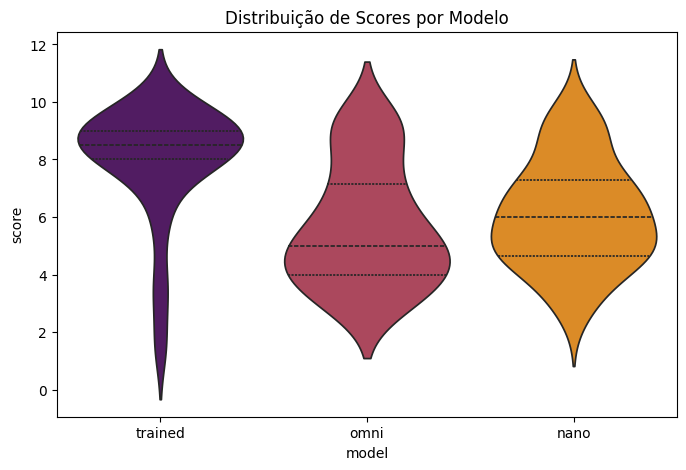

In [53]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df_long, x='model', y='score', inner='quartile', palette='inferno')
plt.title("Distribuição de Scores por Modelo")
plt.savefig('./results/violin_graphic.png')
plt.show() 

C:\Users\mario\AppData\Local\Temp\ipykernel_10804\3630088937.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_long, x='model', y='score', ci='sd', palette='coolwarm')
C:\Users\mario\AppData\Local\Temp\ipykernel_10804\3630088937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x='model', y='score', ci='sd', palette='coolwarm')


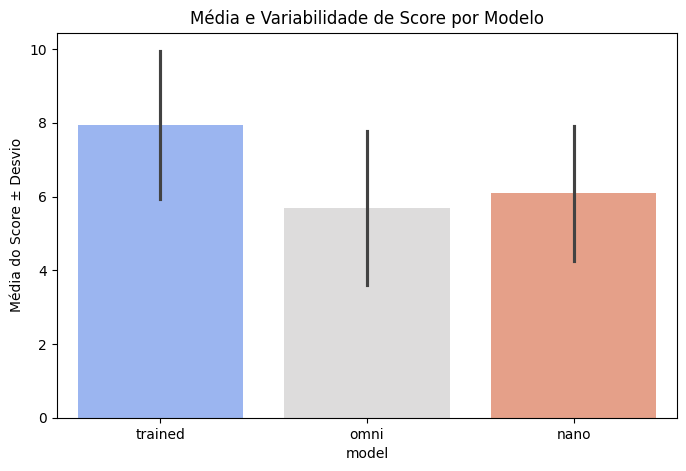

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_long, x='model', y='score', ci='sd', palette='coolwarm')
plt.title("Média e Variabilidade de Score por Modelo")
plt.ylabel("Média do Score ± Desvio")
plt.savefig('./results/mean_and_score_variability.png')
plt.show()

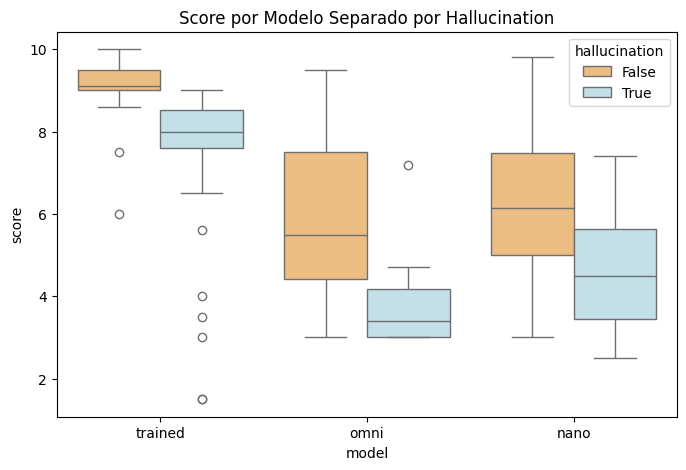

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_long, x='model', y='score', hue='hallucination', palette='RdYlBu')
plt.title("Score por Modelo Separado por Hallucination")
plt.savefig('./results/score_per_model_hallucination.png')
plt.show()

## Métricas Clássicas e de LLM

In [ ]:
import json
try:
    with open('classic_llm_metrics.json', 'r', encoding='utf-8') as arquivo_json:
        ml_metrics = json.load(arquivo_json)
    print(type(ml_metrics))  # Saída: <class 'dict'>
except FileNotFoundError:
    print("Erro: O arquivo 'dados.json' não foi encontrado.")
except json.JSONDecodeError:
    print("Erro: O arquivo não está em um formato JSON válido.")

<class 'dict'>


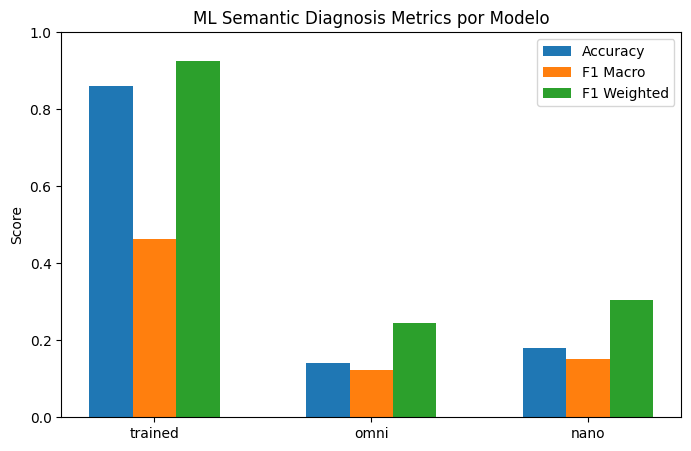

In [57]:
import matplotlib.pyplot as plt

models = list(ml_metrics.keys())
accuracy = [ml_metrics[m]['ml_semantic_diagnosis_metrics']["accuracy_semantic"] for m in models]
f1_macro = [ml_metrics[m]['ml_semantic_diagnosis_metrics']["f1_macro_semantic"] for m in models]
f1_weighted = [ml_metrics[m]['ml_semantic_diagnosis_metrics']["f1_weighted_semantic"] for m in models]

x = range(len(models))
plt.figure(figsize=(8,5))
plt.bar(x, accuracy, width=0.2, label="Accuracy", align='center')
plt.bar([i+0.2 for i in x], f1_macro, width=0.2, label="F1 Macro", align='center')
plt.bar([i+0.4 for i in x], f1_weighted, width=0.2, label="F1 Weighted", align='center')
plt.xticks([i+0.2 for i in x], models)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("ML Semantic Diagnosis Metrics por Modelo")
plt.legend()
plt.savefig('./results/ml_classic_metrics.png')
plt.show()

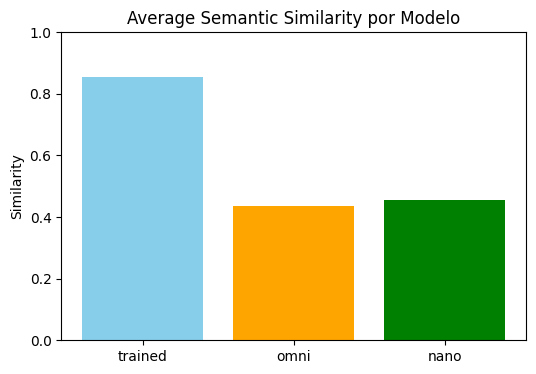

In [58]:
average_similarity = [ml_metrics[m]['ml_semantic_diagnosis_metrics']["average_similarity"] for m in models]

plt.figure(figsize=(6,4))
plt.bar(models, average_similarity, color=['skyblue','orange','green'])
plt.ylim(0,1)
plt.title("Average Semantic Similarity por Modelo")
plt.ylabel("Similarity")
plt.savefig('./results/similarity_per_model.png')
plt.show()

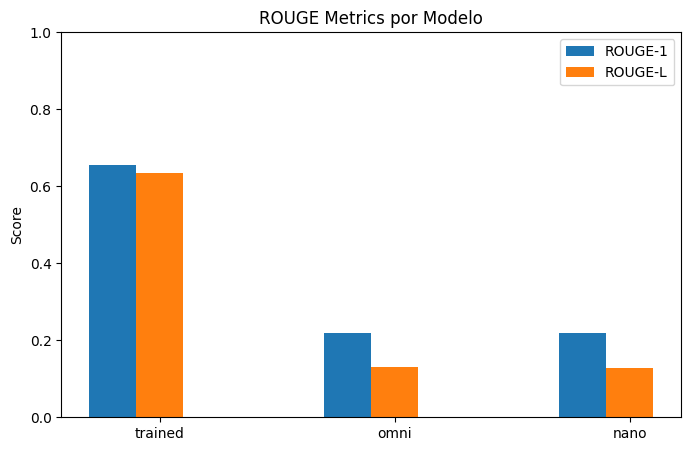

In [59]:
rouge1 = [ml_metrics[m]['llm_text_metrics']["rouge1_fmeasure"] for m in models]
rougeL = [ml_metrics[m]['llm_text_metrics']["rougeL_fmeasure"] for m in models]

x = range(len(models))
plt.figure(figsize=(8,5))
plt.bar(x, rouge1, width=0.2, label="ROUGE-1", align='center')
plt.bar([i+0.2 for i in x], rougeL, width=0.2, label="ROUGE-L", align='center')
plt.xticks([i+0.2 for i in x], models)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("ROUGE Metrics por Modelo")
plt.legend()
plt.savefig('./results/rouge_metrics_per_model.png')
plt.show()

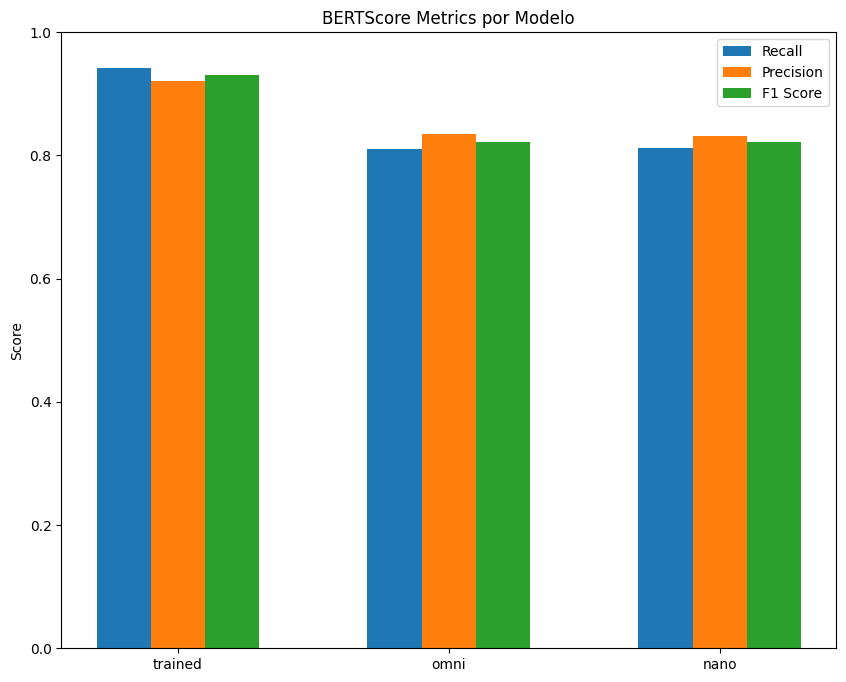

In [60]:
bertscore_recall = [ml_metrics[m]['llm_text_metrics']["bertscore_recall_mean"] for m in models]
bertscore_precision = [ml_metrics[m]['llm_text_metrics']["bertscore_precision_mean"] for m in models]
bertscore_f1 = [ml_metrics[m]['llm_text_metrics']["bertscore_f1_mean"] for m in models]

x = range(len(models))
plt.figure(figsize=(10,8))
plt.bar(x, bertscore_recall, width=0.2, label="Recall", align='center')
plt.bar([i+0.2 for i in x], bertscore_precision, width=0.2, label="Precision", align='center')
plt.bar([i+0.4 for i in x], bertscore_f1, width=0.2, label="F1 Score", align='center')
plt.xticks([i+0.2 for i in x], models)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("BERTScore Metrics por Modelo")
plt.legend()
plt.savefig('./results/bertscore_metrics_per_model.png')
plt.show()

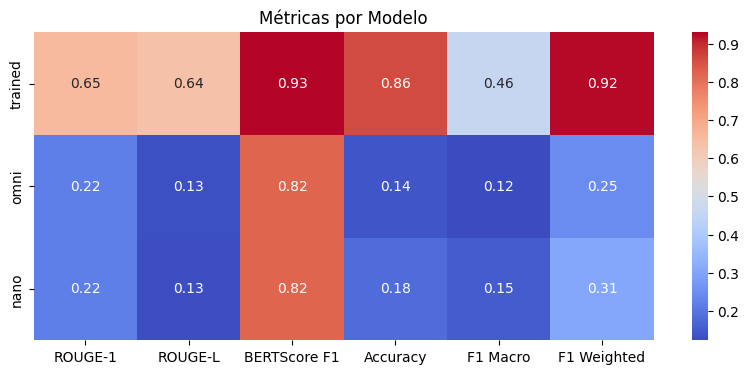

In [61]:
import seaborn as sns
import pandas as pd

df_heat = pd.DataFrame({
    "ROUGE-1": rouge1,
    "ROUGE-L": rougeL,
    "BERTScore F1": bertscore_f1,
    "Accuracy": accuracy,
    "F1 Macro": f1_macro,
    "F1 Weighted": f1_weighted
}, index=models)

plt.figure(figsize=(10,4))
sns.heatmap(df_heat, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Métricas por Modelo")
plt.savefig('./results/ml_metrics_heatmap.png')
plt.show()